In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import time
from wave_cluster import *

%load_ext autoreload
%autoreload 2

### Data

In [2]:
# Country infections, population, geography, and government response data
infections = pd.read_csv("../data/country/infections.csv", index_col = 0)
population = pd.read_csv("../data/country/population.csv", index_col = 0)
geography = pd.read_csv("../data/country/geography.csv", index_col = 0)
gov_response = pd.read_csv("../data/country/gov_response.csv", index_col = 0)

# Normalization of each locations time-series to be cases per 100,000 persons
norm = infections.apply(lambda x: x/(population.loc[x.name].iloc[0]))
infections = norm * 100000 # cases per 100,000

# Windowed average smoothing of each time-series 
# Using average of 7 days in front and behind burrent time-stamp, 
# and repeating 3 times for a smoother result. 
front = 7
back = 7
smoothed = window_average_2d(infections.to_numpy(), front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)

# remove any negative entries (reporting errors still present after smoothing)
smoothed[smoothed < 0] = 0

# fix the indexes
smoothed_index = pd.to_datetime(infections.index[front*3:-back*3])
infections = pd.DataFrame(smoothed, index = smoothed_index, columns = infections.columns)
gov_response = gov_response.iloc[front*3:-back*3]
gov_response.index = pd.to_datetime(gov_response.index)

dataset = infections.to_numpy()

In [3]:
infections.shape[1]

46

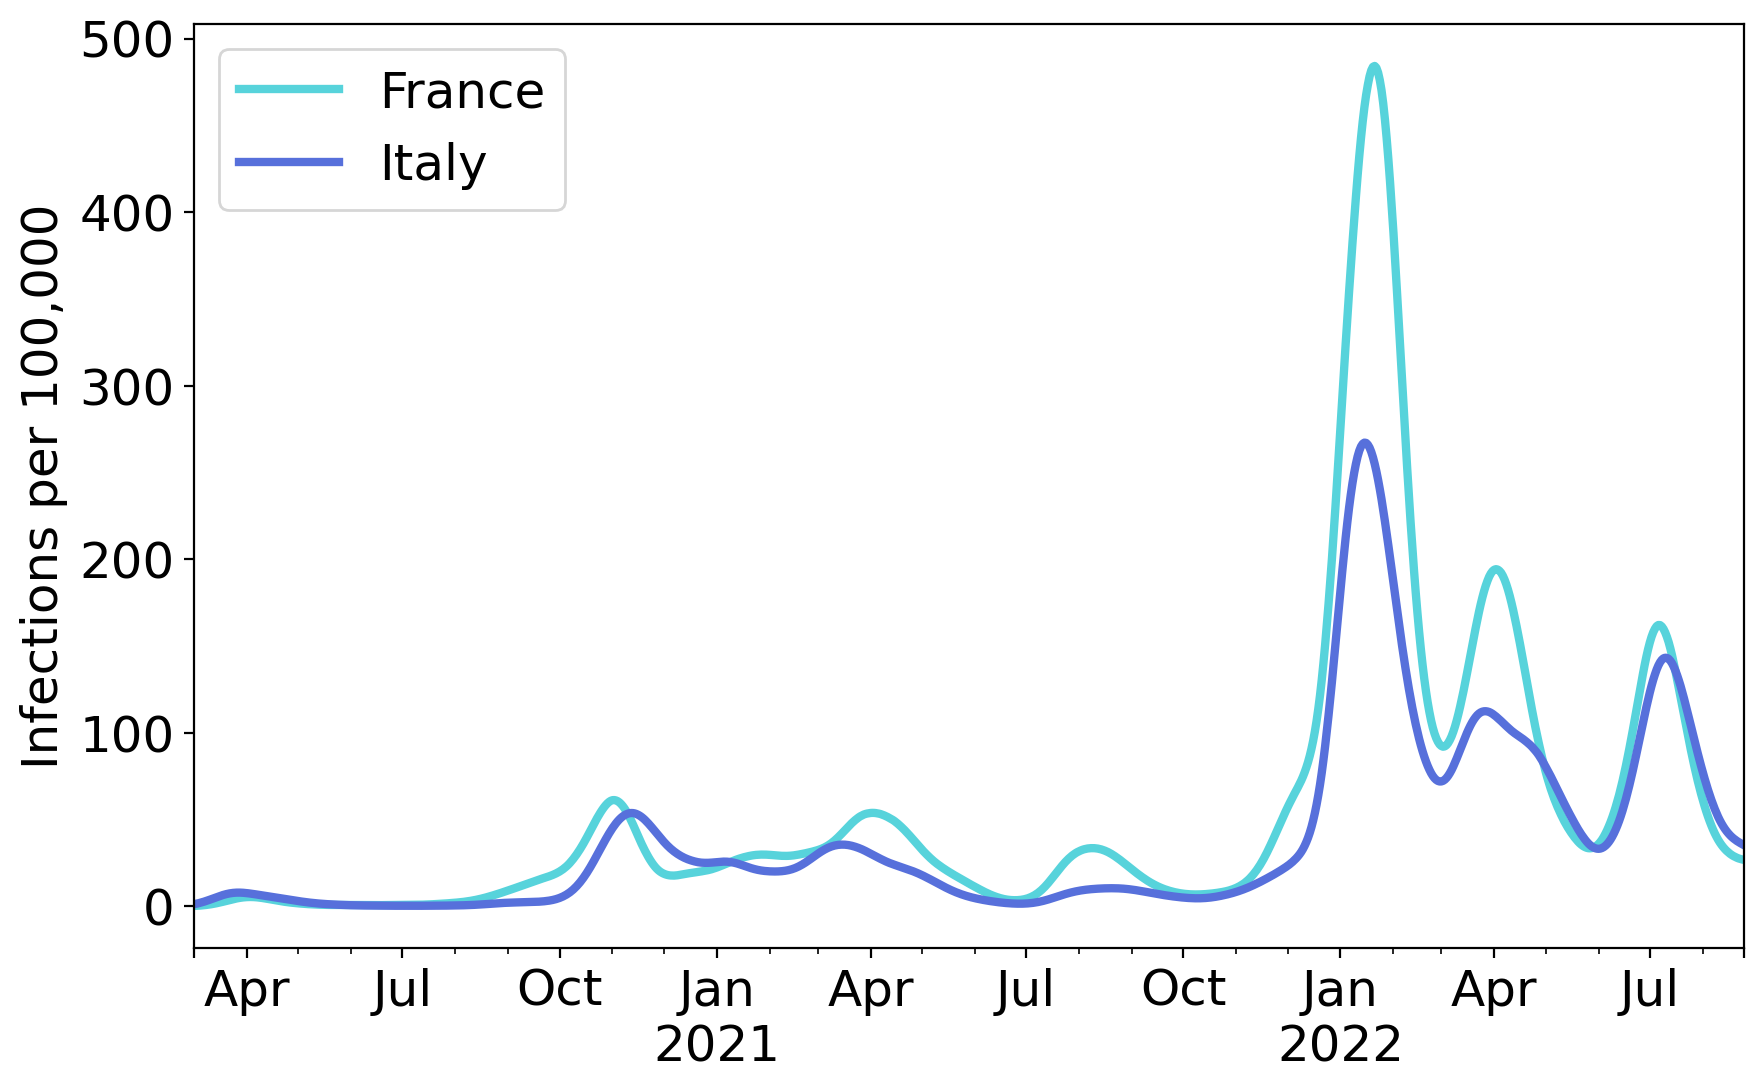

In [15]:
custom_palette = sns.color_palette("hls",8)[4:]
fix,ax = plt.subplots(dpi=200, figsize = (10,6))
plt.rcParams.update({'font.size':18})
sns.color_palette("hls", 8)
locations = ['FR', 'IT']
infections.loc[:,locations].plot(ax=ax, color = custom_palette, linewidth = 3)
#sns.lineplot(data, x = data.index, y = locations[0], palette = 'hls')
#sns.lineplot(data, x = data.index, y = locations[1], palette = 'hls')
ax.set_ylabel('Infections per 100,000')
ax.set_xlabel('')
plt.legend(['France', 'Italy'])

### Map visualization

In [33]:
# shape file with geographic info for each state -- required for graphing
country_map = gpd.read_file(
    "../data/country/visualization/world-administrative-boundaries.shp"
)
country_map = country_map.loc[country_map['iso_3166_1_'].isin(infections.columns)]
country_map = country_map.drop(country_map.loc[country_map.name == "Azores Islands"].index, axis = 0)

In [34]:
country_map

,iso3,status,color_code,name,continent,region,iso_3166_1_,french_shor,geometry
1,CHE,Member State,CHE,Switzerland,Europe,Western Europe,CH,Suisse,"POLYGON ((9.56672 47.54045, 9.5598 47.50209, 9..."
3,AUT,Member State,AUT,Austria,Europe,Western Europe,AT,Autriche,"POLYGON ((16.94618 48.61907, 16.94333 48.57333..."
4,PRT,Member State,PRT,Portugal,Europe,Southern Europe,PT,Portugal,"POLYGON ((-7.43185 37.25319, -7.41903 37.18055..."
5,LUX,Member State,LUX,Luxembourg,Europe,Western Europe,LU,Luxembourg,"POLYGON ((6.36217 49.45939, 6.32833 49.46916, ..."
6,KAZ,Member State,KAZ,Kazakhstan,Asia,Central Asia,KZ,Kazakhstan,"POLYGON ((87.3482 49.09262, 87.31638 49.09777,..."
11,EST,Member State,EST,Estonia,Europe,Northern Europe,EE,Estonie,"MULTIPOLYGON (((22.98485 58.59944, 23.09083 58..."
17,FRA,Member State,FRA,France,Europe,Western Europe,FR,France,"MULTIPOLYGON (((9.4475 42.68305, 9.45014 42.63..."
18,SRB,Member State,SRB,Serbia,Europe,Southern Europe,RS,Serbie,"POLYGON ((20.26102 46.11485, 20.31403 46.06986..."
26,ROU,Member State,ROU,Romania,Europe,Eastern Europe,RO,Roumanie,"POLYGON ((28.21484 45.44865, 28.22698 45.44938..."
27,BLR,Member State,BLR,Belarus,Europe,Eastern Europe,BY,Bélarus,"POLYGON ((31.78388 52.10805, 31.73472 52.1061,..."


(34.0, 73.0)

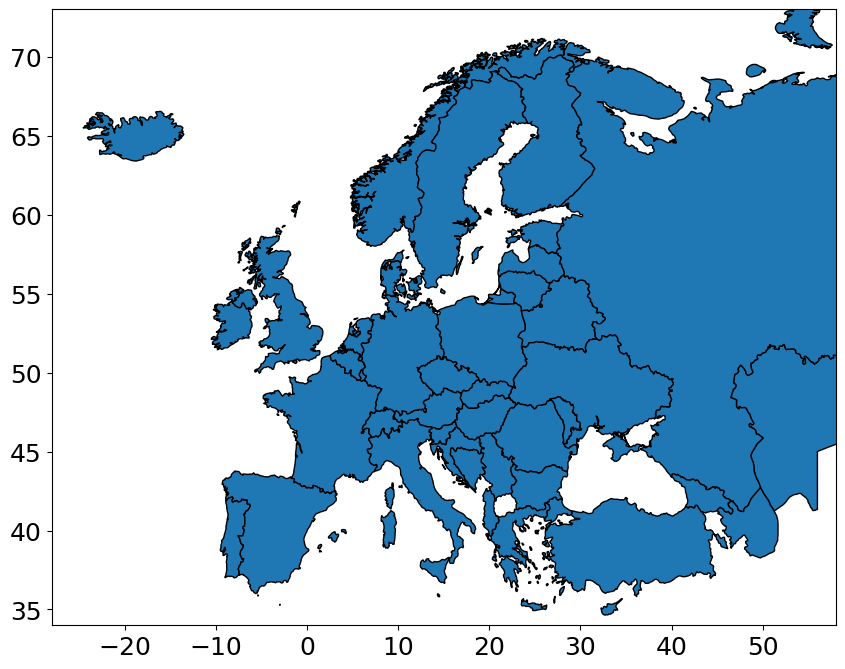

In [38]:
fig,ax = plt.subplots(figsize = (14,8))
country_map.plot(ax = ax, edgecolor="black")
ax.set_xlim(-28,58)
ax.set_ylim(34,73)